# Prática 7 - Teoria dos Jogos
---
**Dupla:**
* Diane Fenzi Gonçalves (2019006574)
* Rubia Alice Moreira de Souza (2022043507)

## Imports
---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import pdb

## Constantes
---

In [ ]:
IDENTIFICADOR_COOPERADOR = 1
IDENTIFICADOR_DESERTOR = 2

## Criação da rede
---

In [ ]:
def criarRede(tamanho: int) -> list[list[object]]:
  matriz = []

  for i in range(tamanho):
    matriz.append([])

    for j in range(tamanho):
      individuo = {
          "tipo": random.randint(
            IDENTIFICADOR_COOPERADOR,
            IDENTIFICADOR_DESERTOR
          ),
          "posicao": (i, j),
          "ganhoTotal": 0
      }

      matriz[i].append(individuo)

  return matriz

## Plot Rede
---

In [ ]:
def extrairTipoIndividuo(rede: list[list[object]]) -> list[list[int]]:
  tiposIndividuo = []

  for i in range(len(rede)):
    tiposIndividuo.append([])

    for j in range(len(rede[i])):
      individuo = rede[i][j]
      tipoIndividuo = individuo['tipo']

      tiposIndividuo[i].append(tipoIndividuo)

  return tiposIndividuo

In [ ]:
def plotGrid(
    grid: list[list[object]],
    titulo: str = 'Simulação Incêndio Florestal'
  ) -> None:

  gridToPlot = extrairTipoIndividuo(grid)

  plt.figure(figsize = (8, 4))
  im = plt.imshow(gridToPlot)

  cmap = {
    1: [0.0, 1.0, 0.0, 1],
    2: [1.0, 0.0, 0.0, 1]
  }
  labels = {1: 'Cooperador', 2: 'Desertor'}
  arrayShow = np.array([[cmap[i] for i in j] for j in gridToPlot])
  patches = [mpatches.Patch(color = cmap[i], label = labels[i]) for i in cmap]

  plt.imshow(arrayShow)
  plt.title(titulo)
  plt.legend(handles = patches, loc = 4, borderaxespad = 0.)
  plt.show()

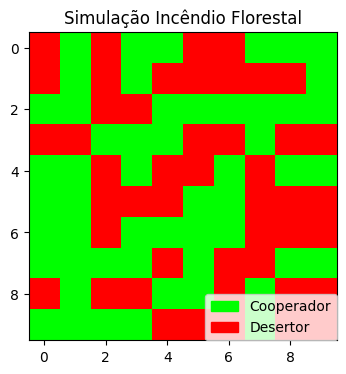

In [ ]:
rede = criarRede(10)
plotGrid(rede)

## Definição da Simulação
---

In [ ]:
def getVizinhoEsquerdo(i: int, j: int, rede):
  if(j == 0):
    return (i, len(rede[i]) - 1)

  return (i, j - 1)

In [ ]:
def getVizinhoDireito(i: int, j: int, rede):
  if(j == len(rede[i]) - 1):
    return (i, 0)

  return (i, j + 1)

In [ ]:
def getVizinhoAcima(i: int, j: int, rede):
  if(i == 0):
    return (len(rede) - 1, j)

  return (i - 1, j)

In [ ]:
def getVizinhoAbaixo(i: int, j: int, rede):
  if(i == len(rede) - 1):
    return (0, j)

  return (i + 1, j)

In [ ]:
def calcularProbabilidadeAdotarEstrategia(
    ganhoVizinhoX: int,
    ganhoVizinhoY: int,
    ruidoK: float
) -> float:
  grauExpo = -((ganhoVizinhoY - ganhoVizinhoX) / ruidoK)
  denominador = 1 + np.exp(grauExpo)

  return 1 / denominador

In [ ]:
def avaliarIndividuo(
    individuo: object,
    rede: list[list[object]],
    b : int,
    ruidoK: float
  ):

  # Realiza contagem do tipo de indivíduos envolta
  contagemDesertores = 0
  contagemCooperadores = 0

  indiceDireito = getVizinhoDireito(
      individuo['posicao'][0],
      individuo['posicao'][1],
      rede
  )
  vizinhoDireito = rede[indiceDireito[0]][indiceDireito[1]]
  if(vizinhoDireito['tipo'] == IDENTIFICADOR_DESERTOR):
    contagemDesertores += 1
  else:
    contagemCooperadores += 1

  indiceEsquerdo = getVizinhoEsquerdo(
    individuo['posicao'][0],
    individuo['posicao'][1],
    rede
  )
  vizinhoEsquerdo = rede[indiceEsquerdo[0]][indiceEsquerdo[1]]
  if(vizinhoEsquerdo['tipo'] == IDENTIFICADOR_DESERTOR):
    contagemDesertores += 1
  else:
    contagemCooperadores += 1

  indiceAcima = getVizinhoAcima(
    individuo['posicao'][0],
    individuo['posicao'][1],
    rede
  )
  vizinhoAcima = rede[indiceAcima[0]][indiceAcima[1]]
  if(vizinhoAcima['tipo'] == IDENTIFICADOR_DESERTOR):
    contagemDesertores += 1
  else:
    contagemCooperadores += 1

  indiceAbaixo = getVizinhoAbaixo(
    individuo['posicao'][0],
    individuo['posicao'][1],
    rede
  )
  vizinhoAbaixo = rede[indiceAbaixo[0]][indiceAbaixo[1]]
  if(vizinhoAbaixo['tipo'] == IDENTIFICADOR_DESERTOR):
    contagemDesertores += 1
  else:
    contagemCooperadores += 1

  # Realiza o calculo do ganho
  if contagemDesertores > contagemCooperadores:
    if individuo['tipo'] == IDENTIFICADOR_COOPERADOR:
      individuo['ganhoTotal'] = 1
    else:
      individuo['ganhoTotal'] = 0
  else:
    if individuo['tipo'] == IDENTIFICADOR_COOPERADOR:
      individuo['ganhoTotal'] = 5
    else:
      individuo['ganhoTotal'] = 4 * b

  # Identifica nova estratégia que será adotada
  vizinhos = [
      vizinhoAbaixo,
      vizinhoAcima,
      vizinhoDireito,
      vizinhoEsquerdo
  ]

  vizinhoEscolhido = random.choice(vizinhos)
  ganhoVizinhoEscolhido = vizinhoEscolhido['ganhoTotal']

  if(ruidoK == 0):
    if(ganhoVizinhoEscolhido > individuo['ganhoTotal']):
      individuo['tipo'] = vizinhoEscolhido['tipo']
  else:
    probabilidadeAdotarEstrategia = calcularProbabilidadeAdotarEstrategia(
      individuo['ganhoTotal'],
      ganhoVizinhoEscolhido,
      ruidoK
    )

    if(random.random() < probabilidadeAdotarEstrategia):
      individuo['tipo'] = vizinhoEscolhido['tipo']


In [ ]:
def passoSimulacao(
    rede: list[list[object]],
    b: int,
    ruidoK: float
):
  for i in range(len(rede)):
    for j in range(len(rede[i])):
      avaliarIndividuo(rede[i][j], rede, b, ruidoK)

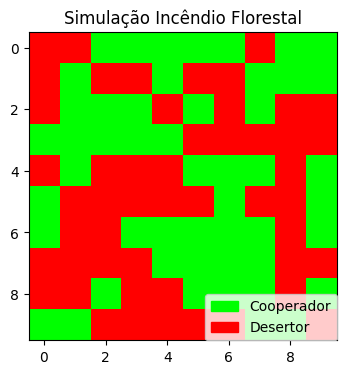

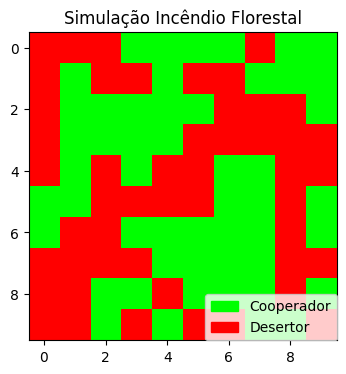

In [ ]:
rede = criarRede(10)
plotGrid(rede)

passoSimulacao(rede, 1, 0)
plotGrid(rede)

In [ ]:
def simular(
    tamanhoRede: int,
    quantidadePassos: int,
    b: int,
    ruidoK: float,
    devePlotar: bool = False
  ) -> None:

  rede = criarRede(tamanhoRede)

  if devePlotar:
    plotGrid(rede, "Estado Inicial")

  for i in range(quantidadePassos):
    passoSimulacao(rede, b, ruidoK)

    if devePlotar:
      plotGrid(rede, f"Iteração {i}")

## Simulação para encontrar o valor de b1
---

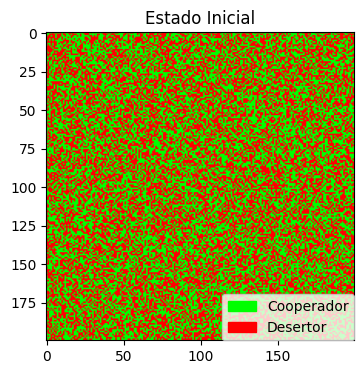

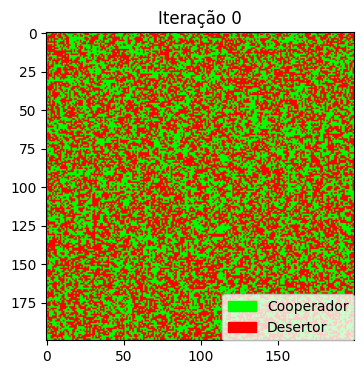

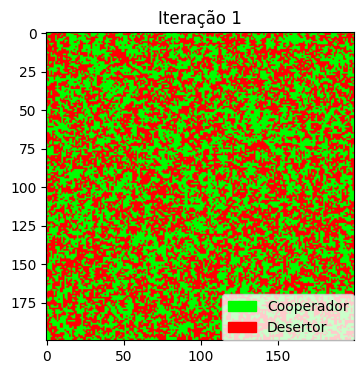

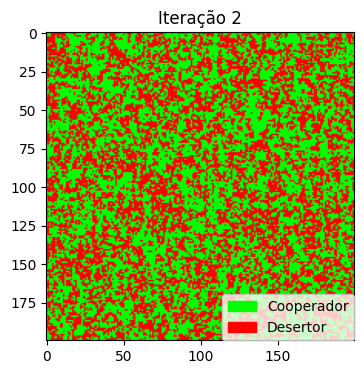

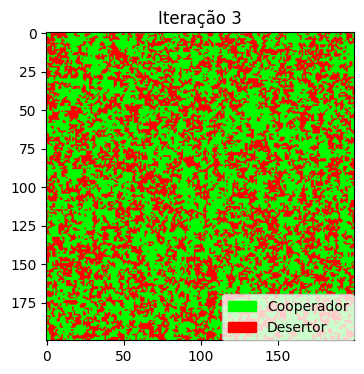

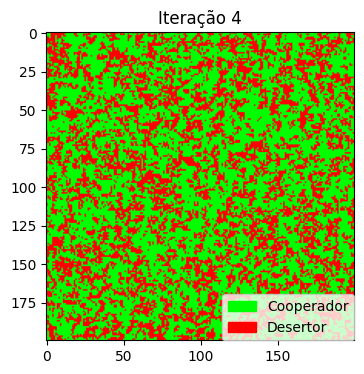

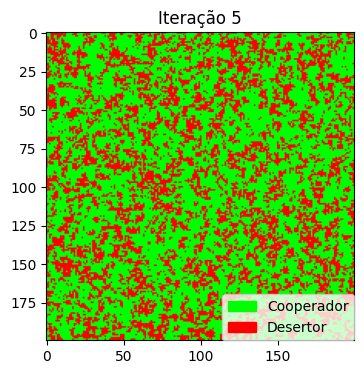

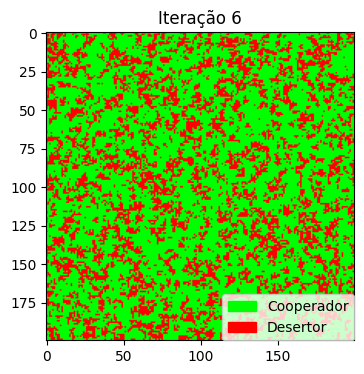

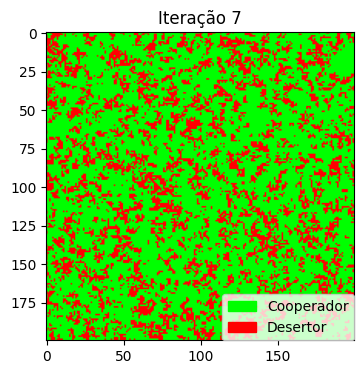

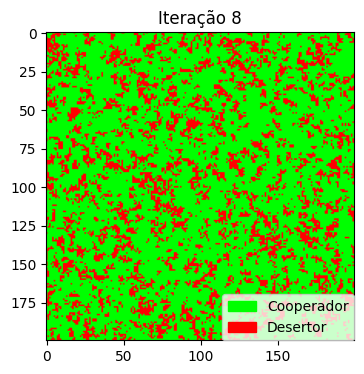

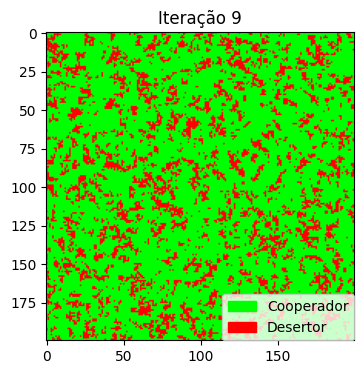

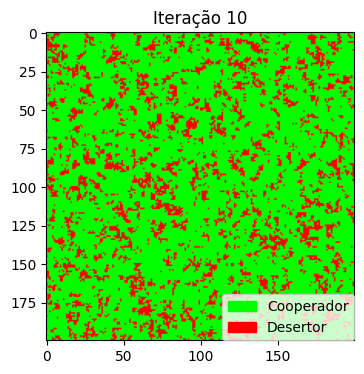

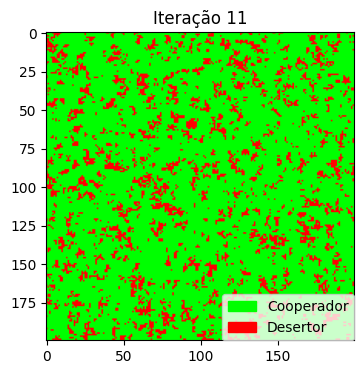

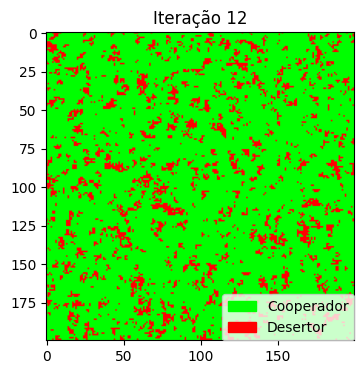

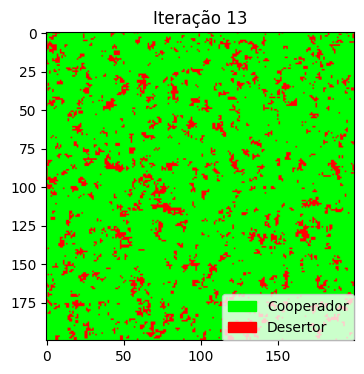

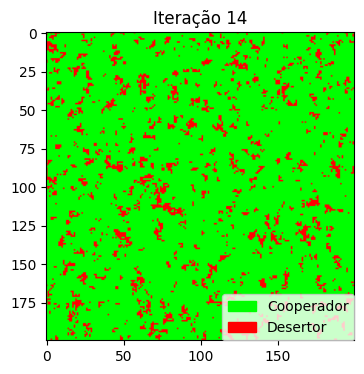

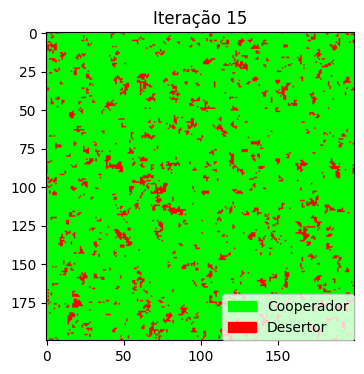

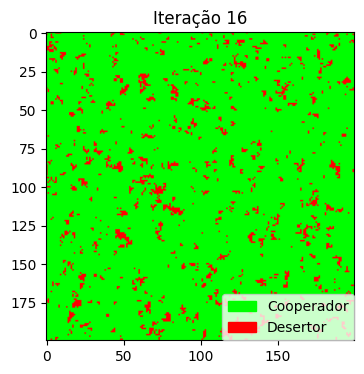

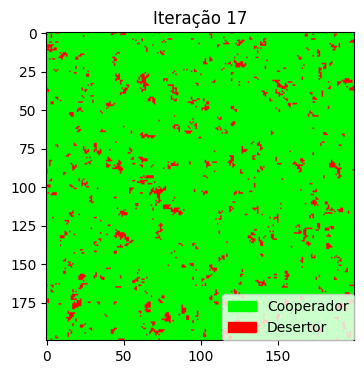

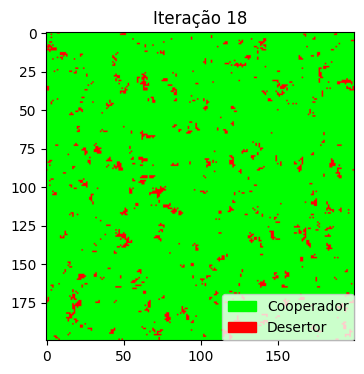

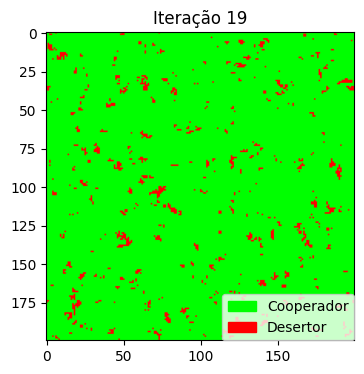

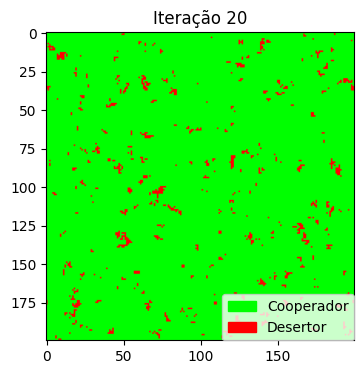

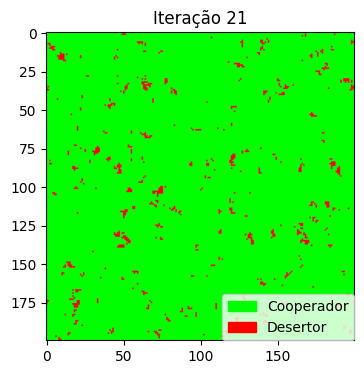

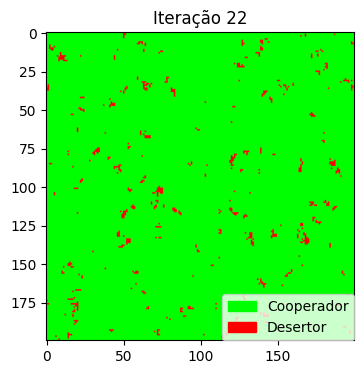

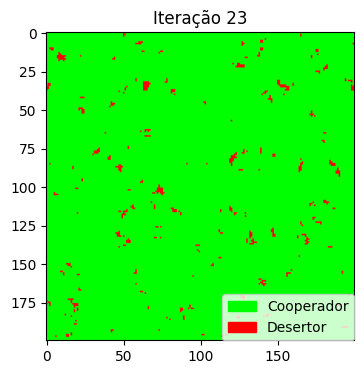

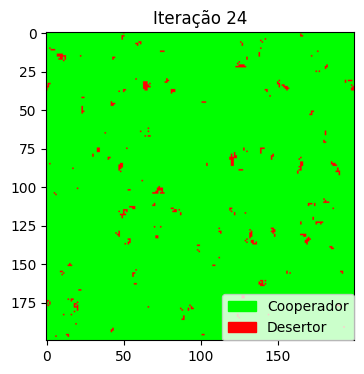

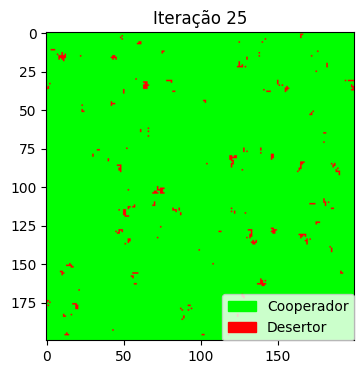

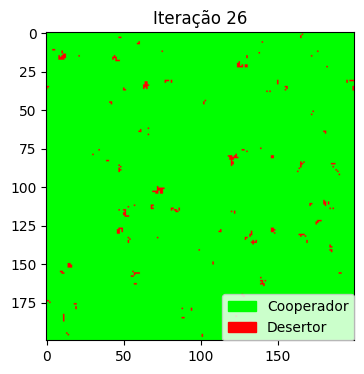

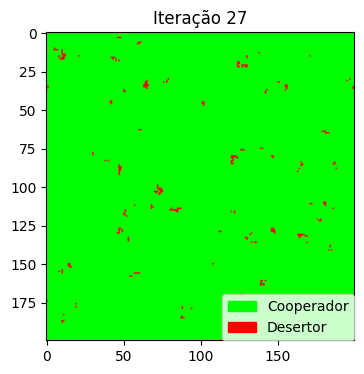

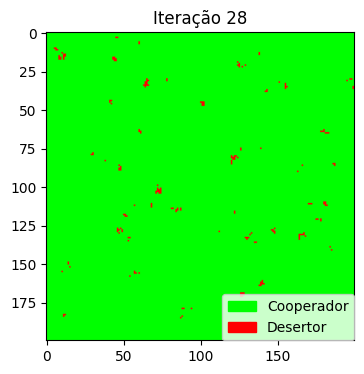

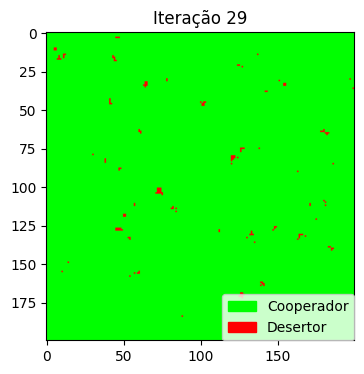

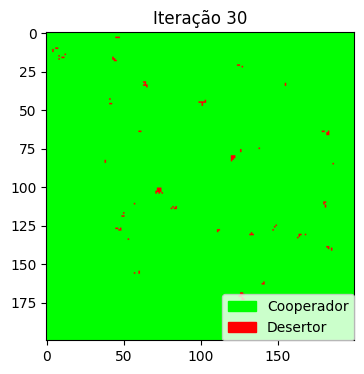

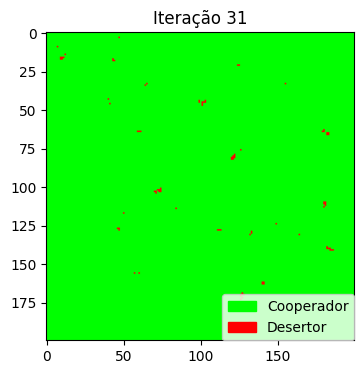

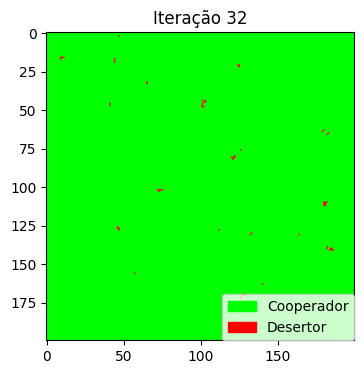

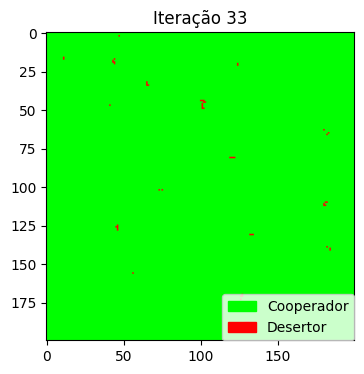

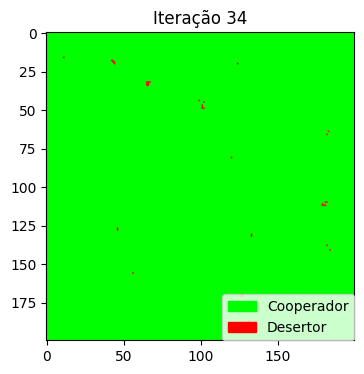

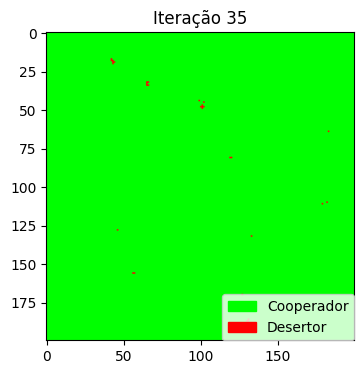

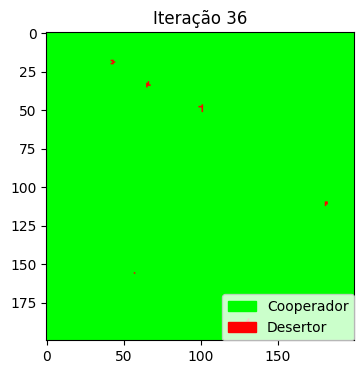

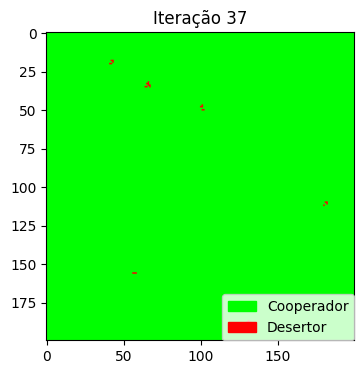

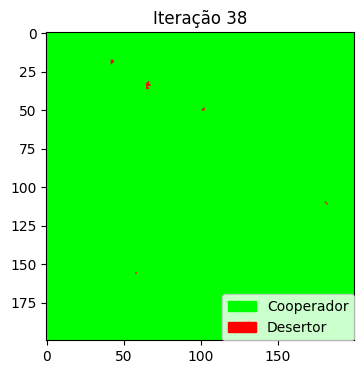

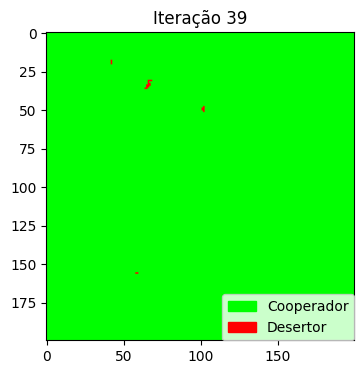

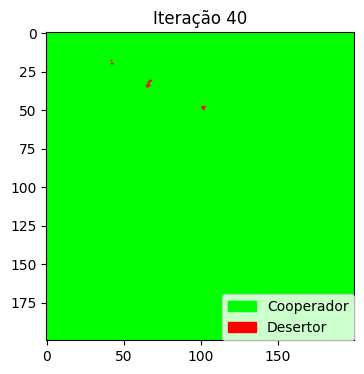

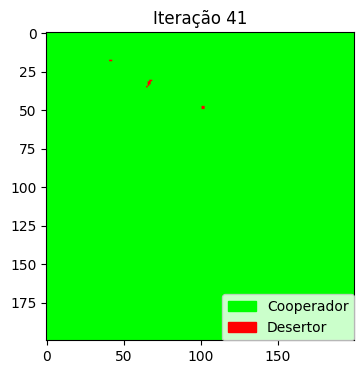

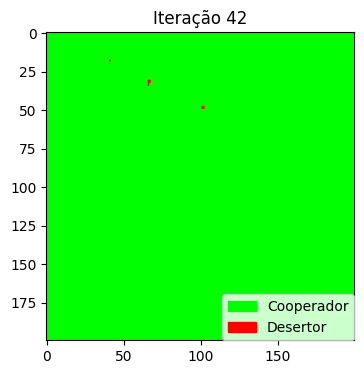

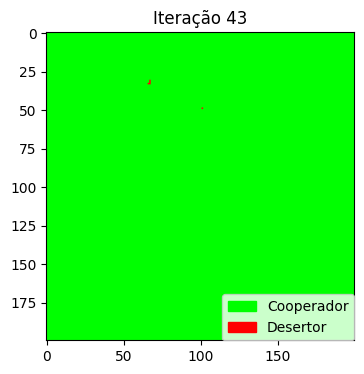

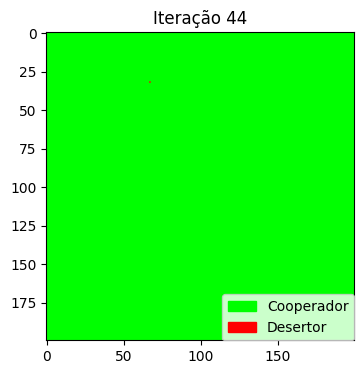

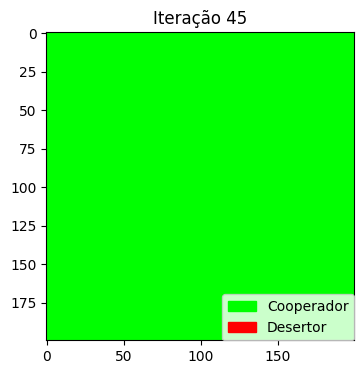

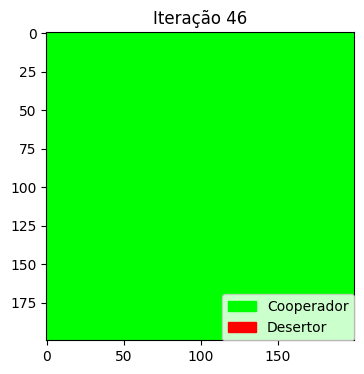

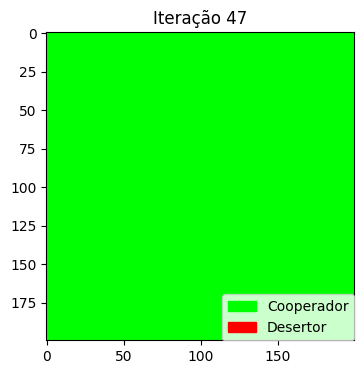

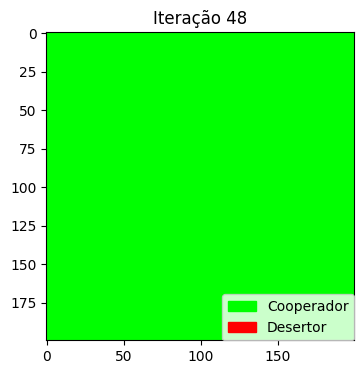

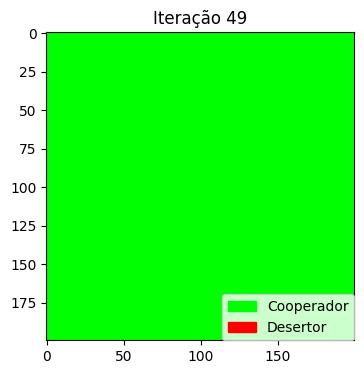

In [ ]:
simular(
    tamanhoRede = 200,
    quantidadePassos = 50,
    b = 1.235,
    ruidoK = 0.25,
    devePlotar = True
)

## Simulação encontrar b2
---

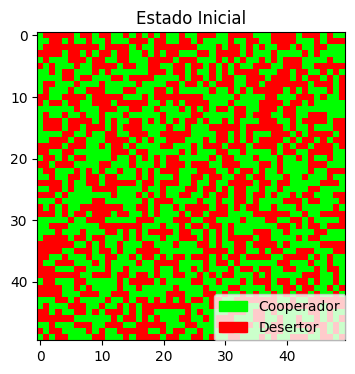

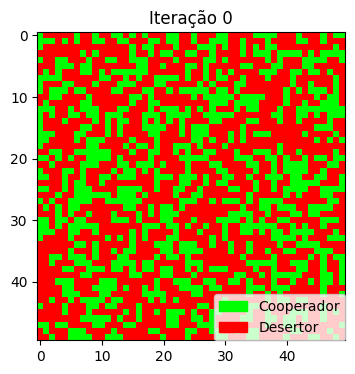

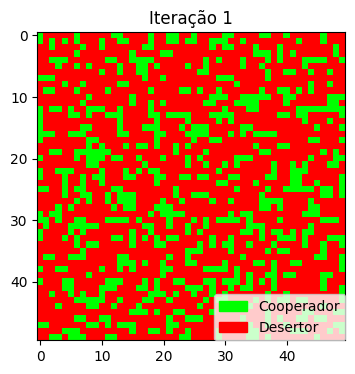

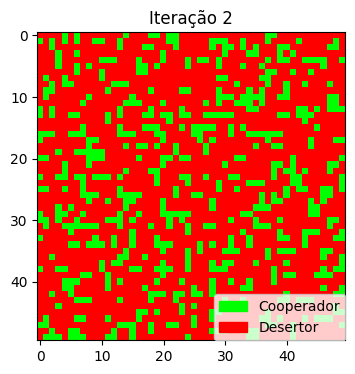

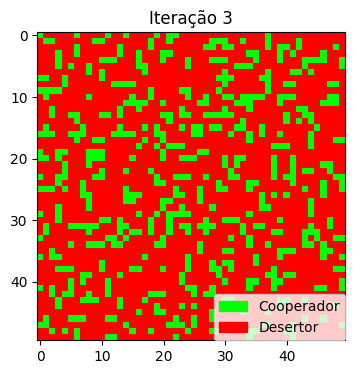

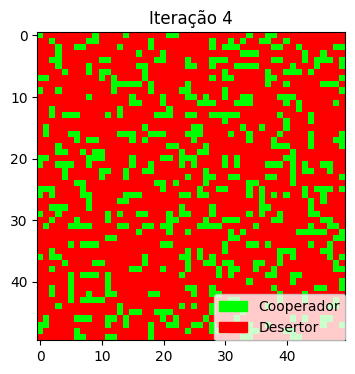

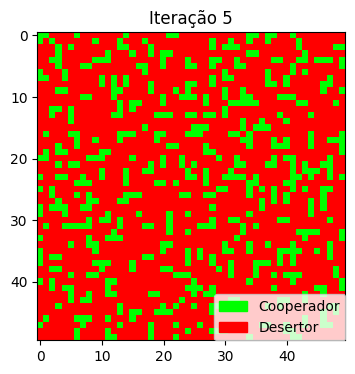

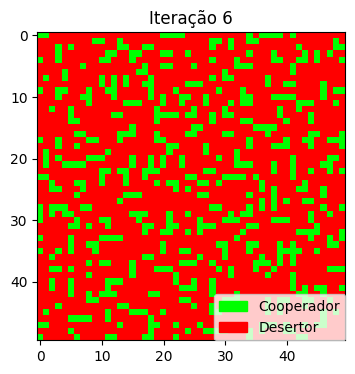

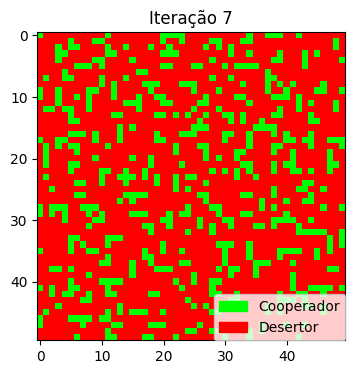

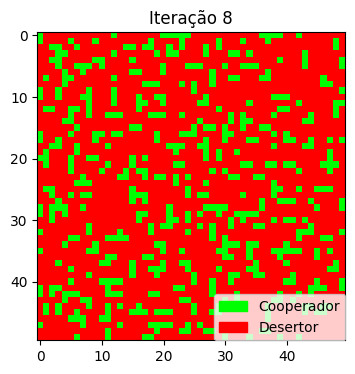

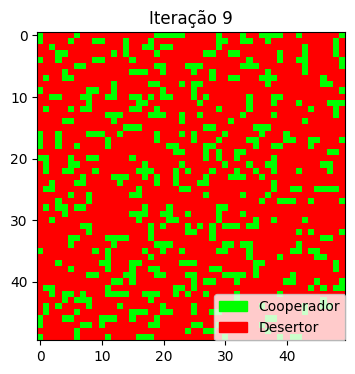

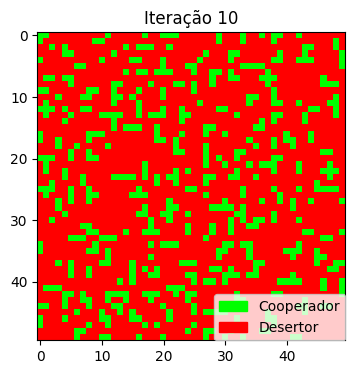

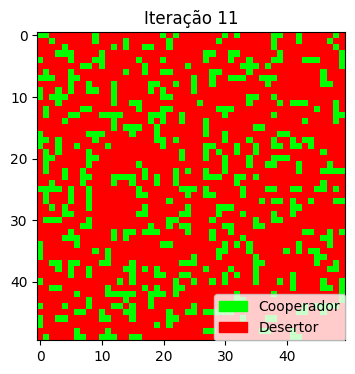

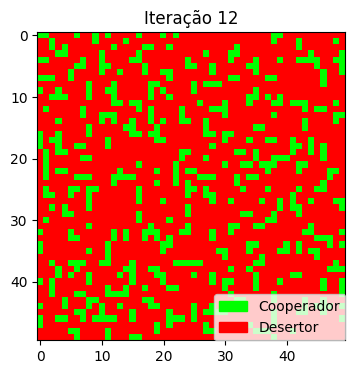

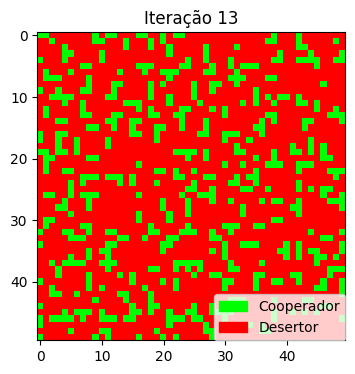

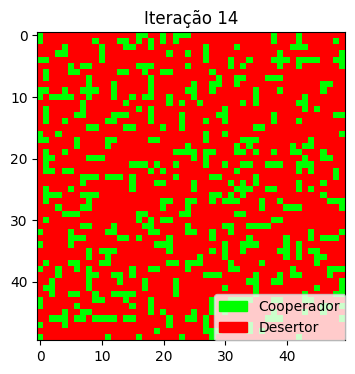

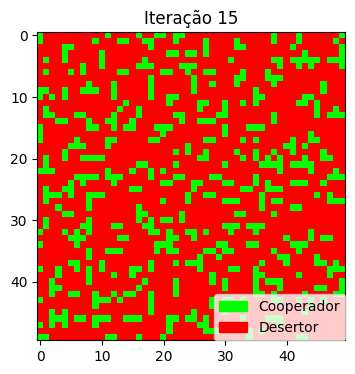

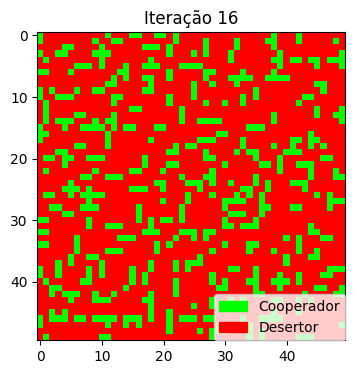

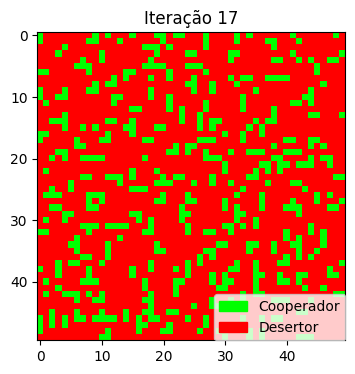

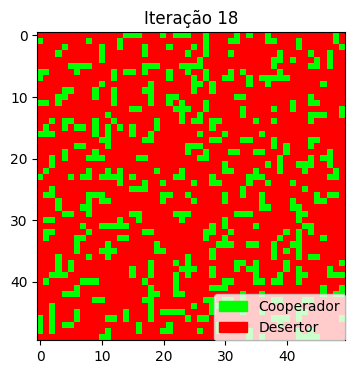

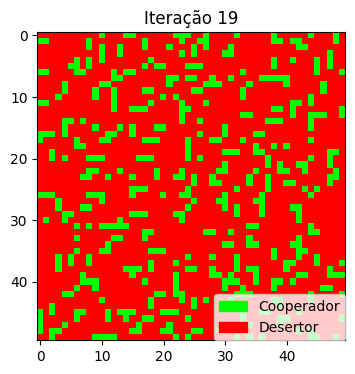

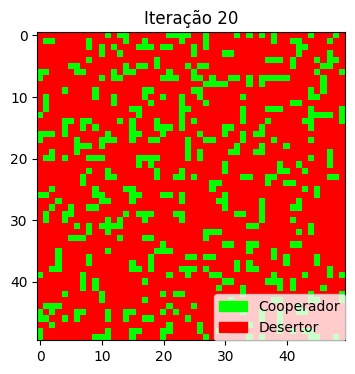

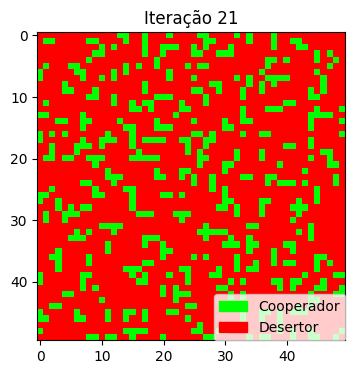

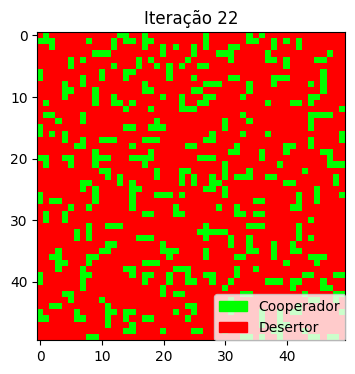

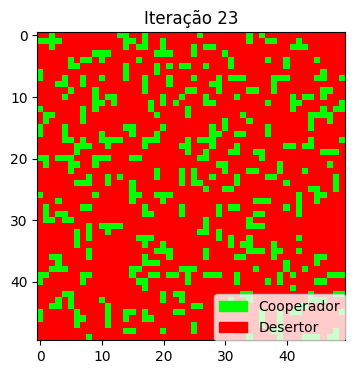

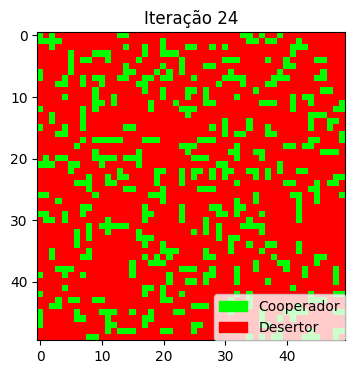

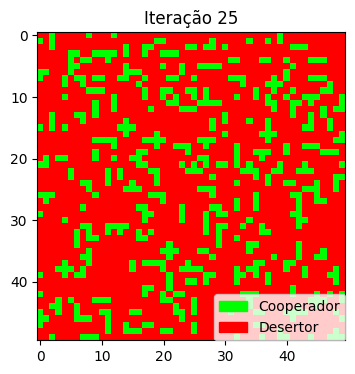

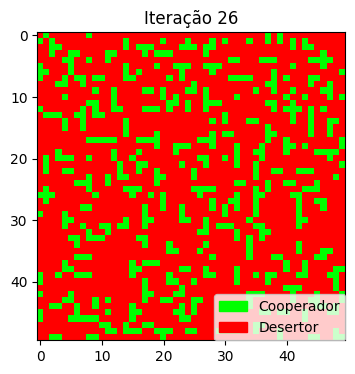

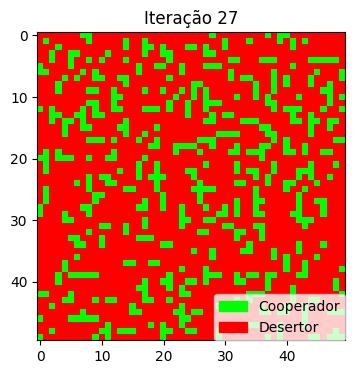

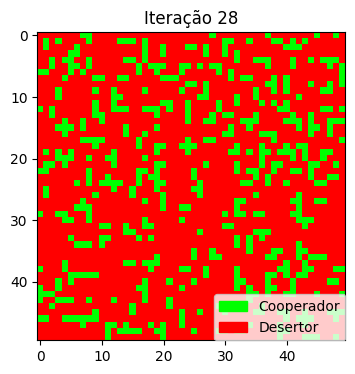

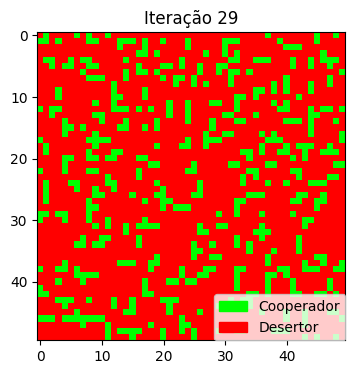

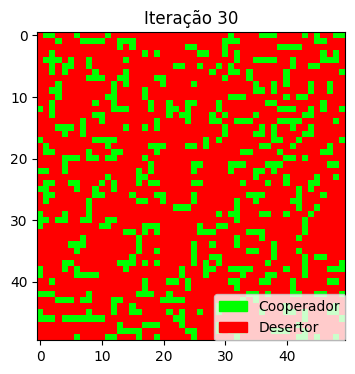

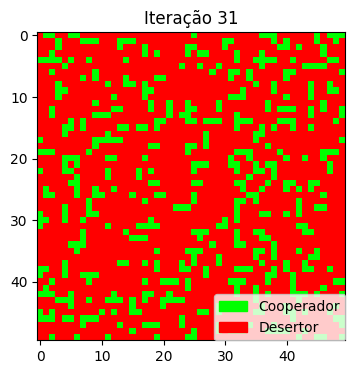

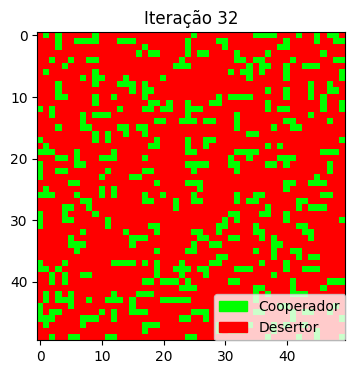

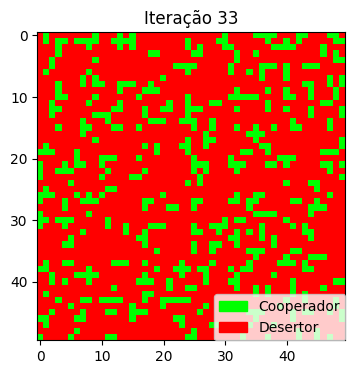

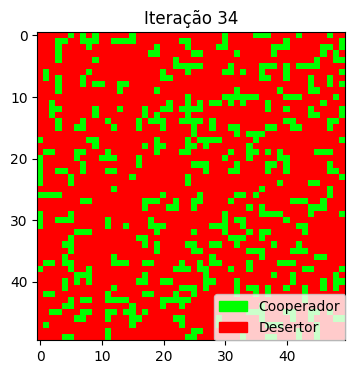

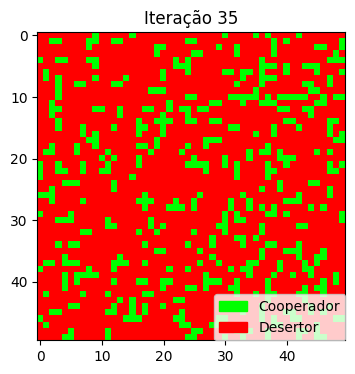

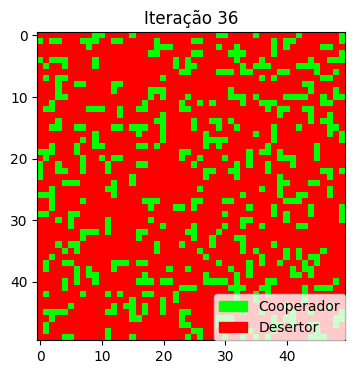

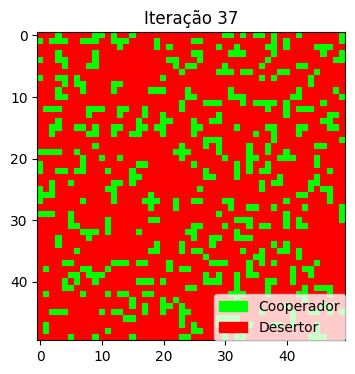

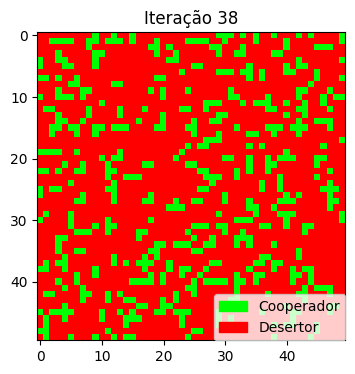

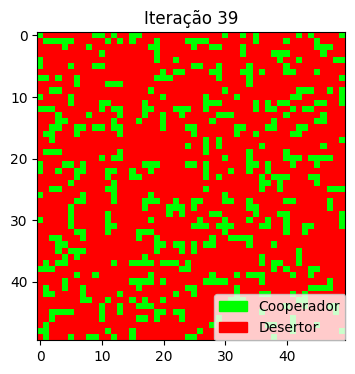

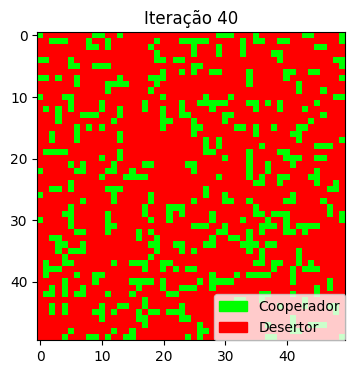

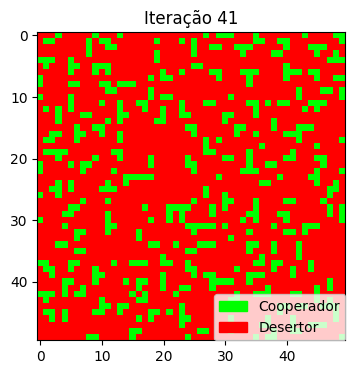

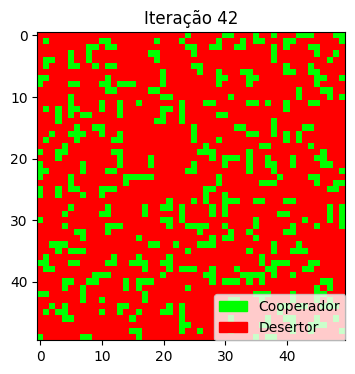

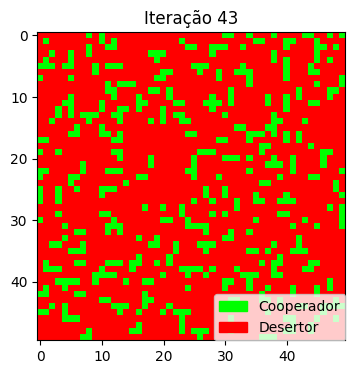

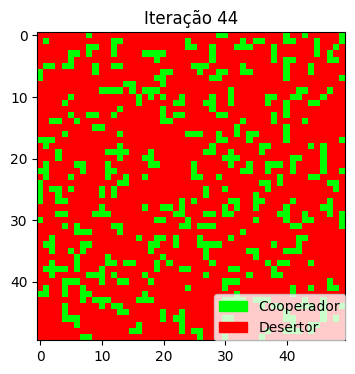

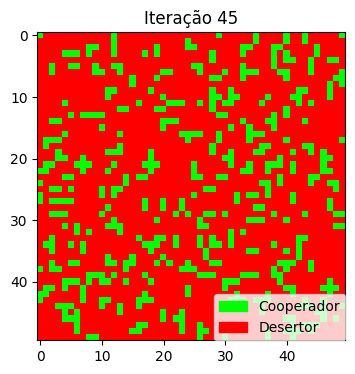

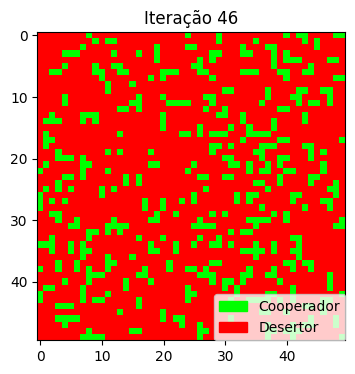

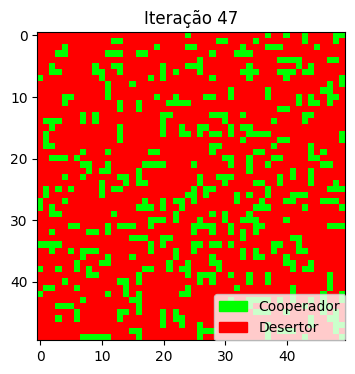

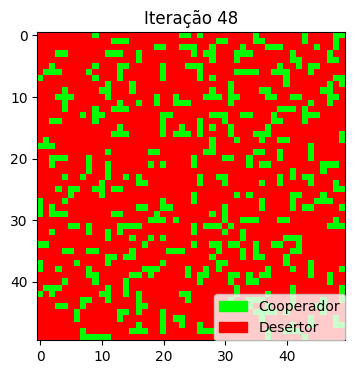

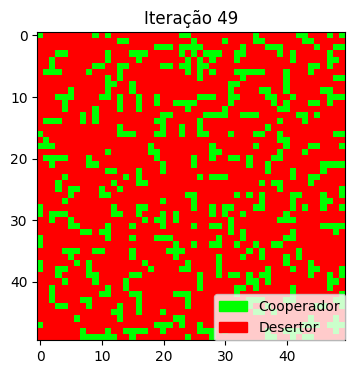

In [ ]:
simular(
    tamanhoRede = 200,
    quantidadePassos = 100,
    b = 1.75,
    ruidoK = 0.25,
    devePlotar = True
)

## Resultados
---

Realizando diversas simulações e restringindo a faixa de valores gradualmente, nós chegamos nos seguintes resultados

* b1 deve ser um valor aproximado de 1.235
* b2 deve ser um valor aproximado de 1.75

No caso de b2, nós não conseguimos realizar simulações suficientes para chegar ao ponto em que todos indivíduos são desertores, o que mostra que a cooperação é um fator bem forte e difícil de ser erradicado. No entanto, é possível notar que com o valor de b2, nas primeiras iterações, grande parte dos indivíduos já se tornam desertores e, ao final da simulação, apenas uma minoria é cooperador.